# PyNRPF v0.1.0  Publication Figures

Figures exported to `outputs/publication_figures/` (PNG, 300 dpi):

1. `fig01_sample_day_mw_vs_ground_truth.png`
2. `fig02_solar_peak_window_hours.png`
3. `fig03_min_threshold_both.png`
4. `fig04_dtr_illustration.png`
5. `fig05_confusion_matrices_1x4.png`


In [1]:
#  Environment + imports
from pathlib import Path
import json
import sys, random

# Make src importable
REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.ticker as mtick

from src.io import (
    load_yaml, req, get,
    verify_sha256_best_effort, load_parquet,
    ensure_dir,
)
from src.validate import basic_validate

PALETTE = {
    "net_load": "#22303d",
    "secondary": "#2F4D67",
    "solar": "#eb932c",
    "accent": "#2E6F73",
}
ZERO_LINE_COLOR = "#111111"

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 22,
    "axes.titlesize": 26,
    "axes.labelsize": 24,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,
    "figure.titlesize": 28,
    "axes.edgecolor": "0.2",
    "axes.labelcolor": "0.1",
    "text.color": "0.1",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "axes.grid": True,
    "grid.color": "0.85",
    "grid.linewidth": 0.6,
})

print("Python:", sys.version)
print("CWD:   ", Path.cwd())
print("REPO:  ", REPO_ROOT)


Python: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
CWD:    C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\notebooks
REPO:   C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper


In [2]:
#  CONFIG
CFG_PATH = REPO_ROOT / "config" / "run.yaml"
cfg = load_yaml(CFG_PATH)
print("Config loaded from:", CFG_PATH)

# -- Run settings
RUN_TAG = str(req(cfg, "run.run_tag"))
SEED    = int(req(cfg, "run.seed"))
random.seed(SEED)
np.random.seed(SEED)

# -- Paths
DATASET_PATH = (REPO_ROOT / str(req(cfg, "paths.dataset_parquet"))).resolve()
SHA_PATH     = (REPO_ROOT / str(req(cfg, "paths.sha256_file"))).resolve()
OUTPUT_DIR   = (REPO_ROOT / str(req(cfg, "paths.output_dir"))).resolve()
PUB_FIG_DIR  = OUTPUT_DIR / "publication_figures"
ensure_dir(PUB_FIG_DIR)
ARCHIVE_FIG_DIR = PUB_FIG_DIR / "archived"
ensure_dir(ARCHIVE_FIG_DIR)
METRICS_JSON = OUTPUT_DIR / f"metrics__{RUN_TAG}.json"

# -- Column names
COL_SITE  = str(req(cfg, "data.columns.site"))
COL_TS    = str(req(cfg, "data.columns.ts"))
COL_NET   = str(req(cfg, "data.columns.net_load"))
COL_SOLAR = str(req(cfg, "data.columns.solar"))
COL_GT    = str(req(cfg, "data.columns.gt"))
ALL_COLS  = [COL_SITE, COL_TS, COL_NET, COL_SOLAR, COL_GT]

# -- Data settings
INTERVAL_MINUTES = int(req(cfg, "data.interval_minutes"))

# -- Validation flags
VERIFY_SHA256           = bool(get(cfg, "validation.verify_sha256_best_effort", True))
STRIP_TIMEZONE          = bool(get(cfg, "validation.strip_timezone", True))
ENFORCE_INTERVAL_ALIGN  = bool(get(cfg, "validation.enforce_interval_alignment", True))
ENFORCE_UNIQUE_KEYS     = bool(get(cfg, "validation.enforce_unique_keys", True))

# -- Train / test split dates
TRAIN_START = str(req(cfg, "split.train_start"))
TRAIN_END   = str(req(cfg, "split.train_end"))
TEST_START  = str(req(cfg, "split.test_start"))
TEST_END    = str(req(cfg, "split.test_end"))

OBSOLETE_PUBLICATION_FIGS = [
    "fig02_dtr_illustration.png",
    "fig03_confusion_matrices_1x4.png",
    "fig03_confusion_matrices_tp_days_only_interval.png",
    "fig04_min_threshold.png",
    "fig05_dtr_illustration.png",
    "fig06_confusion_matrices_1x4.png",
]
for fig_name in OBSOLETE_PUBLICATION_FIGS:
    (PUB_FIG_DIR / fig_name).unlink(missing_ok=True)

print(f"RUN_TAG:  {RUN_TAG}")
print(f"SEED:     {SEED}")
print(f"DATASET:  {DATASET_PATH}")
print(f"METRICS:  {METRICS_JSON}")
print(f"SPLIT:    train {TRAIN_START}..{TRAIN_END} | test {TEST_START}..{TEST_END}")
print(f"FIG_DIR:  {PUB_FIG_DIR}")
print(f"ARCHIVE_FIG_DIR:  {ARCHIVE_FIG_DIR}")


Config loaded from: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\config\run.yaml
RUN_TAG:  local_dev
SEED:     123
DATASET:  C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\dataset\raw\rpf_dataset.parquet
METRICS:  C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\metrics__local_dev.json
SPLIT:    train 2021-11-01..2023-09-30 | test 2023-10-01..2024-09-30
FIG_DIR:  C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures
ARCHIVE_FIG_DIR:  C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\archived


In [3]:
#  Ensure required inputs exist
if not DATASET_PATH.exists():
    print("Dataset not found locally.")
    print("Please place the parquet at:", DATASET_PATH)
    raise SystemExit("Stopping: no local dataset available.")

if not METRICS_JSON.exists():
    raise FileNotFoundError(f"Metrics JSON not found: {METRICS_JSON}")

local_path = DATASET_PATH
print("Parquet found locally:", local_path)
print("Metrics JSON found:", METRICS_JSON)


Parquet found locally: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\dataset\raw\rpf_dataset.parquet
Metrics JSON found: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\metrics__local_dev.json


In [4]:
#  Load dataset
if VERIFY_SHA256:
    sha_result = verify_sha256_best_effort(local_path, SHA_PATH)
    print("SHA-256 check:", sha_result["status"],
          f"({sha_result.get('note', '')})" if sha_result.get("note") else "")

df = load_parquet(local_path)
print(df.dtypes)
df.head()


SHA-256 check: ok 
Loaded 1,011,264 rows x 5 cols from rpf_dataset.parquet
substation_id                         object
timestamp                datetime64[ns, UTC]
net_load_MW                          float64
solar_MW                             float64
net_load_ground_truth                float64
dtype: object


,substation_id,timestamp,net_load_MW,solar_MW,net_load_ground_truth
0,A,2021-11-01 00:15:00+00:00,NaN,0.0,NaN
1,A,2021-11-01 00:30:00+00:00,NaN,0.0,NaN
2,A,2021-11-01 00:45:00+00:00,NaN,0.0,NaN
3,A,2021-11-01 01:00:00+00:00,NaN,0.0,NaN
4,A,2021-11-01 01:15:00+00:00,12.515586,0.0,12.515586


In [5]:
#  Validation
result = basic_validate(
    df,
    cols_required=ALL_COLS,
    site_col=COL_SITE,
    ts_col=COL_TS,
    key_cols=[COL_SITE, COL_TS],
    interval_minutes=INTERVAL_MINUTES,
    strip_timezone=STRIP_TIMEZONE,
    enforce_interval_alignment=ENFORCE_INTERVAL_ALIGN,
    enforce_unique_keys=ENFORCE_UNIQUE_KEYS,
)

df = result["df"]
summary = result["summary"]

print("Validation passed.")
for k, v in summary.items():
    print(f"  {k}: {v}")


Validation passed.
  n_rows: 1011264
  n_sites: 10
  n_duplicate_keys: 0
  min_ts: 2021-11-01 00:15:00
  max_ts: 2024-09-30 00:00:00
  null_substation_id: 0
  null_timestamp: 0
  null_net_load_MW: 3000
  null_solar_MW: 1040
  null_net_load_ground_truth: 3000


In [6]:
#  Train / test split
df["date"] = df[COL_TS].dt.date

train_mask = (df["date"] >= pd.Timestamp(TRAIN_START).date()) & (df["date"] <= pd.Timestamp(TRAIN_END).date())
test_mask  = (df["date"] >= pd.Timestamp(TEST_START).date())  & (df["date"] <= pd.Timestamp(TEST_END).date())

df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

print(f"Train: {len(df_train):,} rows  ({TRAIN_START} to {TRAIN_END})")
print(f"Test:  {len(df_test):,} rows  ({TEST_START} to {TEST_END})")
print(f"Other: {(~train_mask & ~test_mask).sum():,} rows outside split range")


Train: 666,432 rows  (2021-11-01 to 2023-09-30)
Test:  344,832 rows  (2023-10-01 to 2024-09-30)
Other: 0 rows outside split range


In [7]:
#  Model reruns are not required for publication figures
print("Skipping model retraining in this notebook.")
print("The locked sample-day figures are built directly from the validated dataset.")


Skipping model retraining in this notebook.
The locked sample-day figures are built directly from the validated dataset.


In [8]:
#  Metrics source for confusion-matrix figures
print("Confusion-matrix figures will be rendered from:", METRICS_JSON)


Confusion-matrix figures will be rendered from: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\metrics__local_dev.json


In [9]:
#  Load the locked publication sample day
SAMPLE_SITE = "F"
SAMPLE_DATE = pd.Timestamp("2024-02-17").date()
SAMPLE_SITE_LABEL = "Substation F"

sample_day = df_test.loc[
    (df_test[COL_SITE] == SAMPLE_SITE) & (df_test["date"] == SAMPLE_DATE)
].copy()
sample_day = sample_day.sort_values(COL_TS)
if sample_day.empty:
    raise RuntimeError(f"Locked publication sample not found: {SAMPLE_SITE} on {SAMPLE_DATE}")

daytime_mask = (sample_day[COL_TS].dt.hour >= 6) & (sample_day[COL_TS].dt.hour < 18)
sample_daytime_rpf_count = int((sample_day.loc[daytime_mask, COL_GT] < 0).sum())

print("Locked publication sample day:")
print(f"  site: {SAMPLE_SITE}")
print(f"  date: {SAMPLE_DATE}")
print(f"  daytime GT-RPF intervals: {sample_daytime_rpf_count}")
print(f"  label: {SAMPLE_SITE_LABEL}")


Locked publication sample day:
  site: F
  date: 2024-02-17
  daytime GT-RPF intervals: 16
  label: Substation F


Saved: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig01_sample_day_mw_vs_ground_truth.png


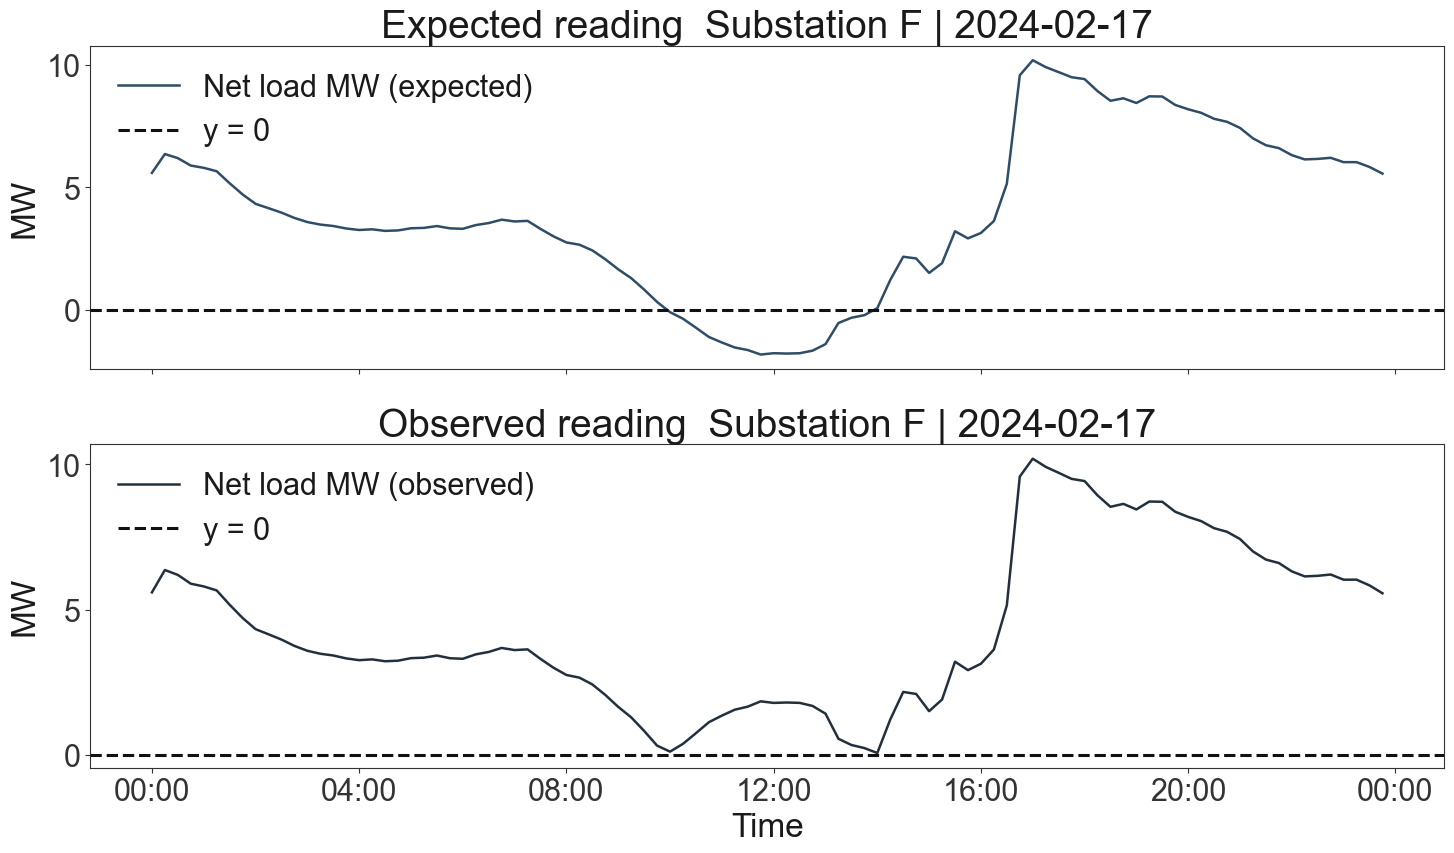

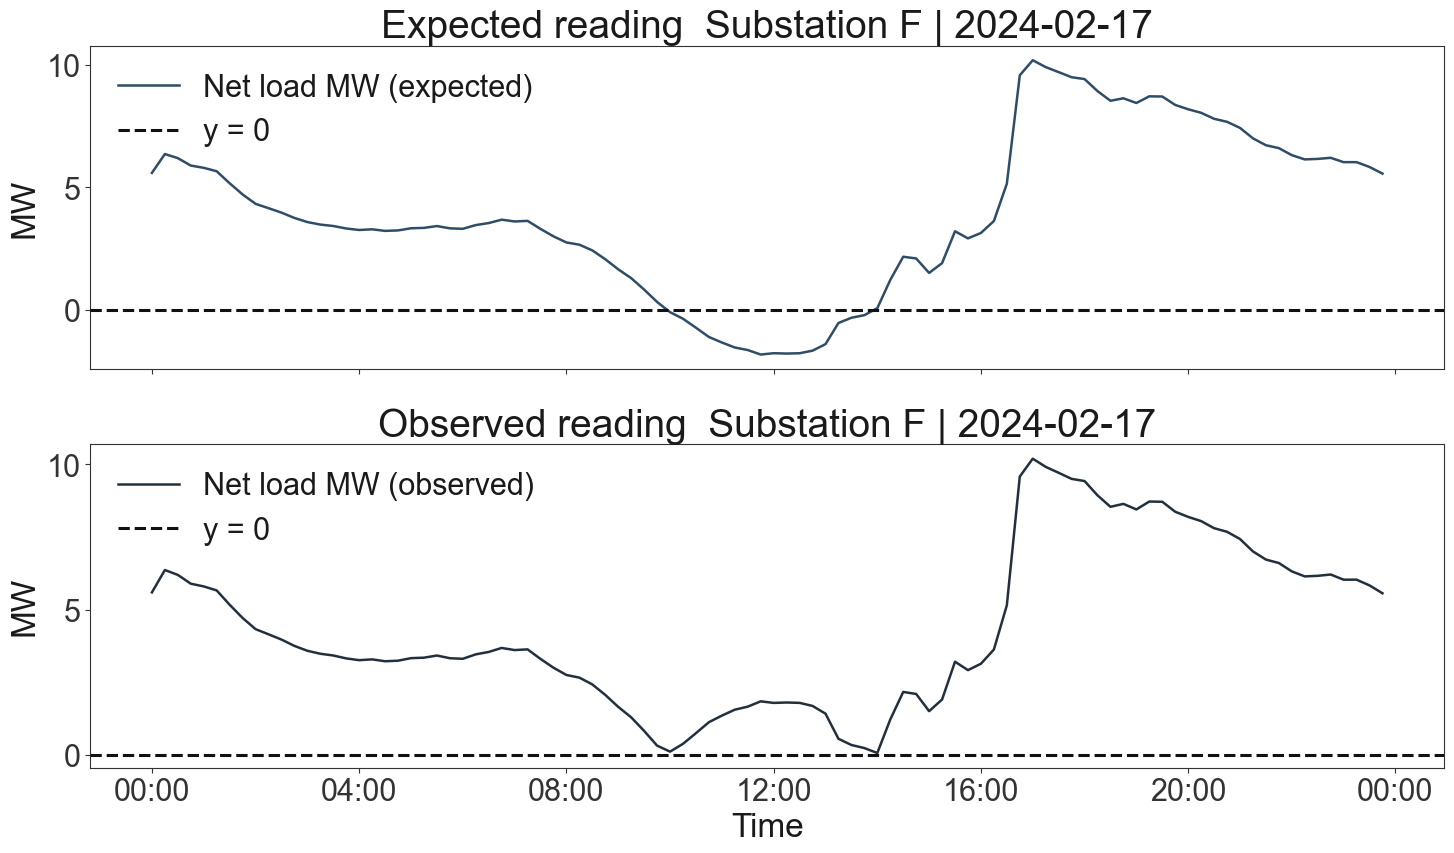

In [10]:
#  Figure 1: Sample day time plot (ground truth vs net load)
fig1_path = PUB_FIG_DIR / "fig01_sample_day_mw_vs_ground_truth.png"

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
x = sample_day[COL_TS]

for ax in axes:
    ax.set_axisbelow(True)
    ax.grid(False)

axes[0].plot(x, sample_day[COL_GT], color=PALETTE["secondary"], linewidth=1.8, label="Net load MW (expected)")
axes[0].axhline(0, color=ZERO_LINE_COLOR, linewidth=2.2, linestyle="--", zorder=5, label="y = 0")
axes[0].set_ylabel("MW", fontsize=24)
axes[0].set_title(f"Expected reading  {SAMPLE_SITE_LABEL} | {SAMPLE_DATE}", fontsize=28)
axes[0].legend(loc="upper left", frameon=False, fontsize=22)

axes[1].plot(x, sample_day[COL_NET], color=PALETTE["net_load"], linewidth=1.8, label="Net load MW (observed)")
axes[1].axhline(0, color=ZERO_LINE_COLOR, linewidth=2.2, linestyle="--", zorder=5, label="y = 0")
axes[1].set_ylabel("MW", fontsize=24)
axes[1].set_xlabel("Time", fontsize=24)
axes[1].set_title(f"Observed reading  {SAMPLE_SITE_LABEL} | {SAMPLE_DATE}", fontsize=28)
axes[1].legend(loc="upper left", frameon=False, fontsize=22)

axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=4))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
for ax in axes:
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.tick_params(axis="both", labelsize=22)
fig.tight_layout()
fig.savefig(fig1_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig1_path}")
fig


Saved: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig02_solar_peak_window_hours.png
Saved: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig03_min_threshold_both.png


Saved: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig04_dtr_illustration.png


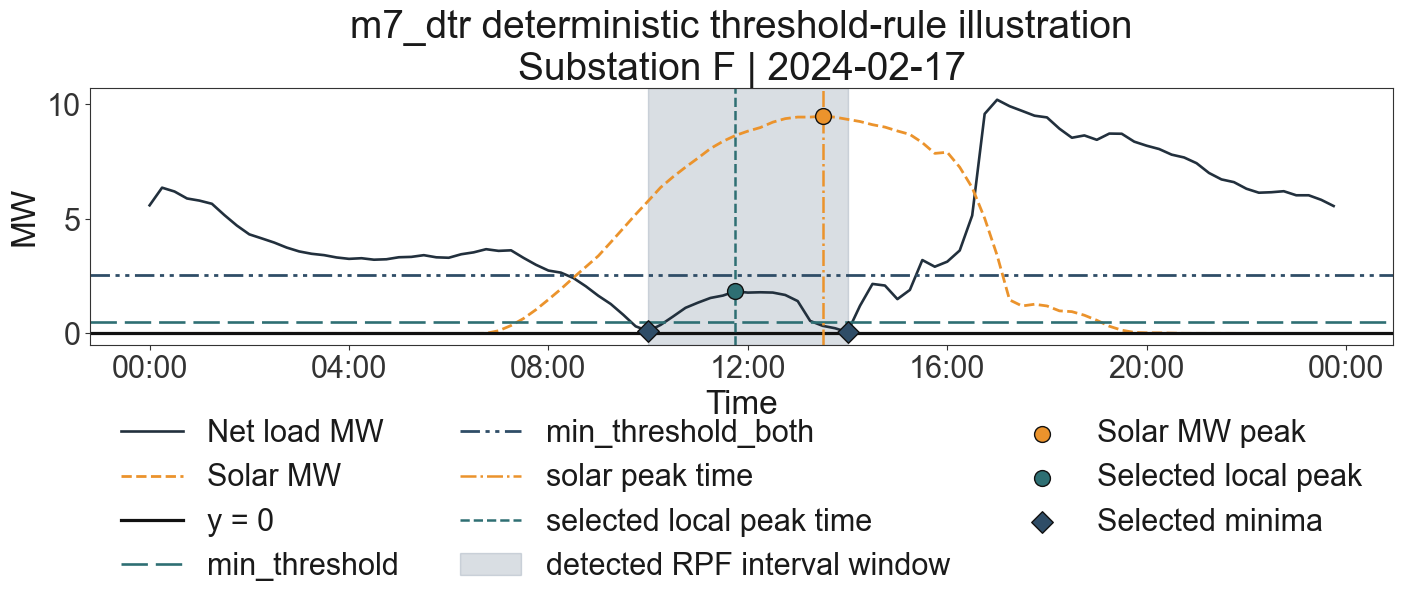

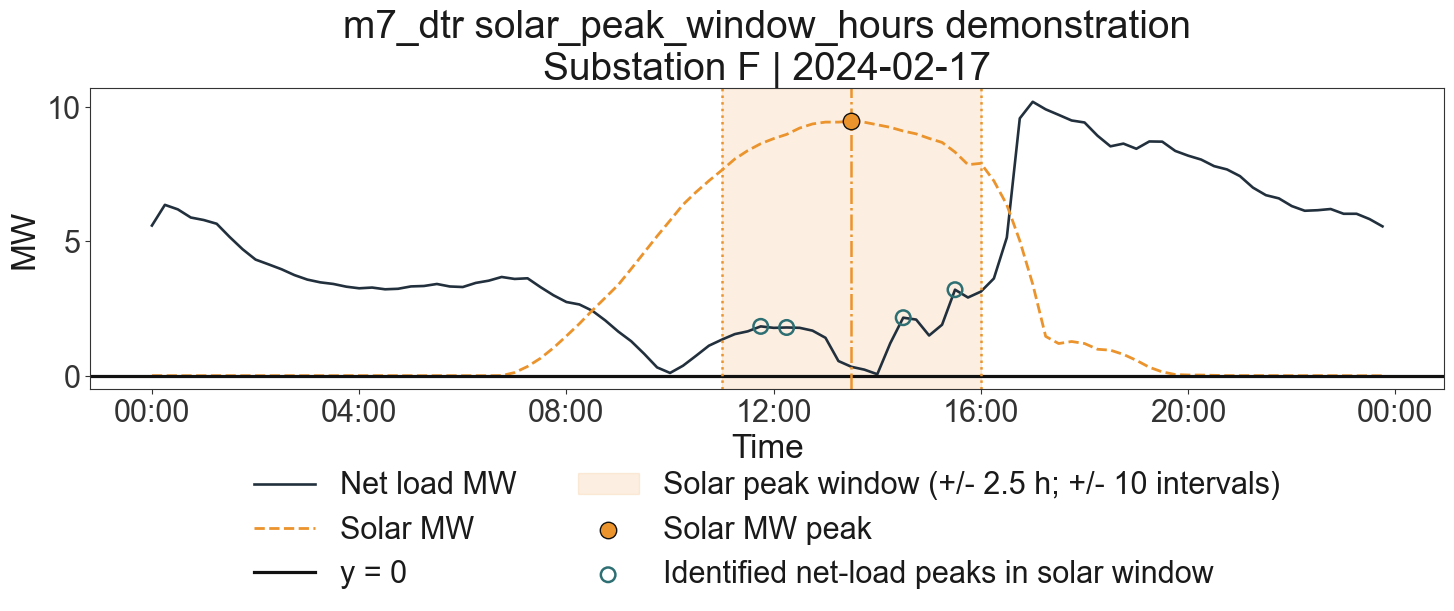

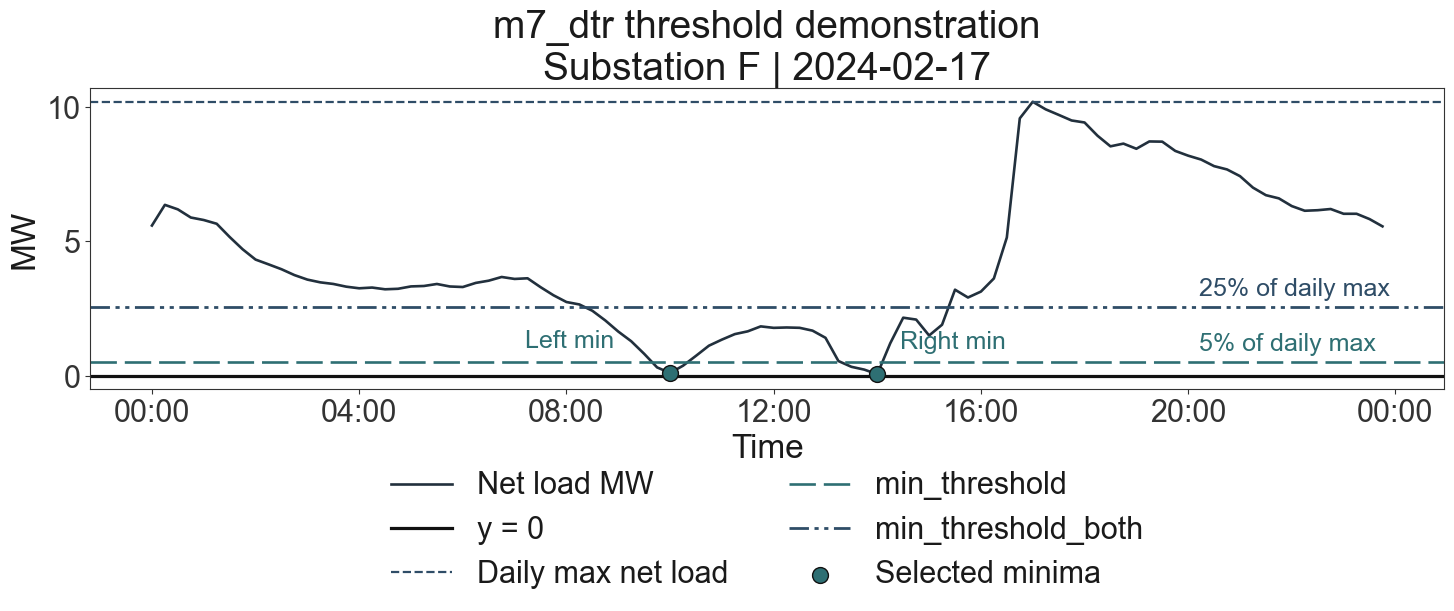

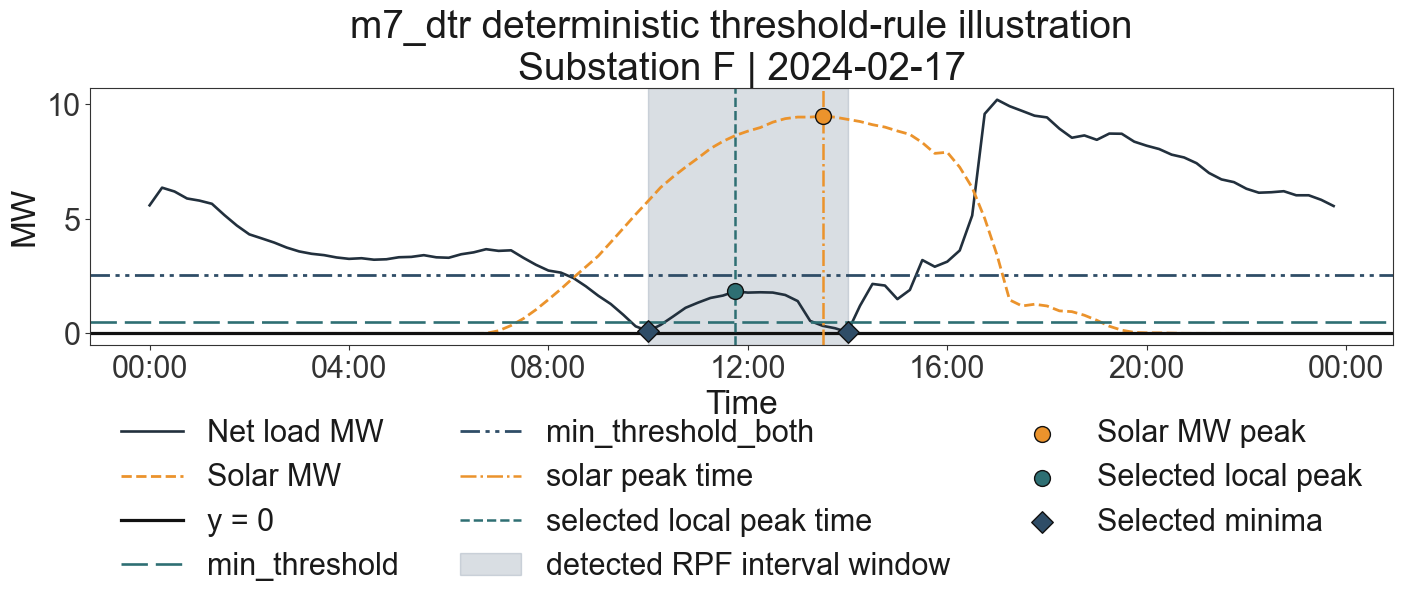

In [11]:
#  Figures 2-4: m7_dtr explanatory views and full illustration
_NS_PER_HOUR = 3_600_000_000_000
_NS_PER_MIN = 60_000_000_000
_NS_PER_SEC = 1_000_000_000


def _parse_time_ns(s: str) -> int:
    parts = [int(part) for part in str(s).strip().split(":")]
    while len(parts) < 3:
        parts.append(0)
    return (
        parts[0] * _NS_PER_HOUR
        + parts[1] * _NS_PER_MIN
        + parts[2] * _NS_PER_SEC
    )


def _style_time_axis(ax):
    ax.set_xlabel("Time", fontsize=24)
    ax.set_ylabel("MW", fontsize=24)
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.tick_params(axis="both", labelsize=22)
    ax.grid(False)


THRESHOLD_STYLE = (0, (10, 3))
THRESHOLD_BOTH_STYLE = (0, (7, 2, 1.5, 2, 1.5, 2))


def extract_m7_single_day_diag(day_df: pd.DataFrame, cfg: dict) -> dict:
    m7 = req(cfg, "m7_threshold")
    window_minutes = int(m7["peak_window_minutes"])
    min_threshold = float(req(m7, "min_threshold"))
    min_threshold_both = float(req(m7, "min_threshold_both"))

    d = day_df.sort_values(COL_TS).copy()
    ts = d[COL_TS].values.astype("datetime64[ns]").astype(np.int64)
    mw = d[COL_NET].values.astype(float)
    solar = d[COL_SOLAR].values.astype(float)

    if np.any(np.isnan(mw)):
        raise RuntimeError("Sample day has missing MW; DTR diagnostic not available.")
    if np.any(mw < 0):
        raise RuntimeError("Sample day has already-negative MW; DTR day gate fails.")

    day0 = pd.Timestamp(d[COL_TS].iloc[0]).normalize()
    midnight = int(day0.to_datetime64().astype("datetime64[ns]").astype(np.int64))

    secs = (ts - midnight) / _NS_PER_SEC
    midday = (secs >= 21600) & (secs < 64800)
    if midday.sum() < 3:
        raise RuntimeError("Sample day has <3 midday points; DTR day gate fails.")

    max_mw = float(np.nanmax(mw))
    threshold = max_mw * min_threshold
    threshold_both = max_mw * min_threshold_both

    mi = np.where(midday)[0]
    ts_m, mw_m, sol_m = ts[mi], mw[mi], solar[mi]

    tb_i64 = midnight + _parse_time_ns(str(m7["solar_peak_tiebreak_time"]))
    win_ns = int(window_minutes * 60 * _NS_PER_SEC)

    sol_ok = ~np.isnan(sol_m)
    if sol_ok.any():
        si = np.where(sol_ok)[0]
        dist = np.abs(ts_m[si] - tb_i64)
        order = np.lexsort((ts_m[si], dist, -sol_m[si]))
        solar_peak_ts = int(ts_m[si][order[0]])
        solar_peak_mw = float(sol_m[si][order[0]])
        solar_window_start = solar_peak_ts - win_ns
        solar_window_end = solar_peak_ts + win_ns
    else:
        solar_peak_ts = int(midnight + 12 * _NS_PER_HOUR)
        solar_peak_mw = float("nan")
        solar_window_start = int(midnight + 10 * _NS_PER_HOUR)
        solar_window_end = int(midnight + 15 * _NS_PER_HOUR - 1)

    lmax = np.zeros(len(mw_m), dtype=bool)
    if len(mw_m) >= 3:
        lmax[1:-1] = (mw_m[1:-1] > mw_m[:-2]) & (mw_m[1:-1] > mw_m[2:])

    cand = np.where((ts_m >= solar_window_start) & (ts_m <= solar_window_end) & lmax)[0]
    if len(cand) == 0:
        raise RuntimeError("No DTR candidates in solar window for sample day.")

    best = None
    for c in cand:
        peak_ts = int(ts_m[c])
        peak_mw = float(mw_m[c])

        lm_mask = (ts < peak_ts) & (mw < threshold_both)
        rm_mask = (ts > peak_ts) & (mw < threshold_both)
        if not lm_mask.any() or not rm_mask.any():
            continue

        li = np.where(lm_mask)[0]
        ri = np.where(rm_mask)[0]
        l_idx = li[int(np.argmin(mw[li]))]
        r_idx = ri[int(np.argmin(mw[ri]))]

        left_mw = float(mw[l_idx])
        left_ts = int(ts[l_idx])
        right_mw = float(mw[r_idx])
        right_ts = int(ts[r_idx])
        rank = (left_mw + right_mw, -peak_mw)
        payload = {
            "peak_ts": peak_ts,
            "peak_mw": peak_mw,
            "left_ts": left_ts,
            "left_mw": left_mw,
            "right_ts": right_ts,
            "right_mw": right_mw,
            "rank": rank,
        }
        if best is None or rank < best["rank"]:
            best = payload

    if best is None:
        raise RuntimeError("No valid left/right minima pair found for DTR diagnostic.")
    if not (best["left_mw"] < threshold or best["right_mw"] < threshold):
        raise RuntimeError("Threshold gate failed on sample day for DTR diagnostic.")

    return {
        "max_mw": max_mw,
        "threshold": threshold,
        "threshold_both": threshold_both,
        "min_threshold": min_threshold,
        "min_threshold_both": min_threshold_both,
        "solar_peak_ts": pd.to_datetime(solar_peak_ts, unit="ns"),
        "solar_peak_mw": solar_peak_mw,
        "solar_window_start": pd.to_datetime(solar_window_start, unit="ns"),
        "solar_window_end": pd.to_datetime(solar_window_end, unit="ns"),
        "window_hours": round(window_minutes / 60.0, 1),
        "window_intervals": int(round(window_minutes / INTERVAL_MINUTES)),
        "candidate_peak_ts": pd.to_datetime(ts_m[cand], unit="ns"),
        "candidate_peak_mw": mw_m[cand].astype(float),
        "selected_peak_ts": pd.to_datetime(best["peak_ts"], unit="ns"),
        "selected_peak_mw": best["peak_mw"],
        "left_min_ts": pd.to_datetime(best["left_ts"], unit="ns"),
        "left_min_mw": best["left_mw"],
        "right_min_ts": pd.to_datetime(best["right_ts"], unit="ns"),
        "right_min_mw": best["right_mw"],
    }


def _plot_threshold_figure(fig_path: Path, title: str):
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(sample_day[COL_TS], sample_day[COL_NET], color=PALETTE["net_load"], linewidth=1.9, label="Net load MW")
    ax.axhline(0, color=ZERO_LINE_COLOR, linestyle="-", linewidth=2.3, label="y = 0")
    ax.axhline(diag["max_mw"], color=PALETTE["secondary"], linestyle="--", linewidth=1.6, label="Daily max net load")
    ax.axhline(
        diag["threshold"],
        color=PALETTE["accent"],
        linestyle=THRESHOLD_STYLE,
        linewidth=1.9,
        label="min_threshold",
    )
    ax.axhline(
        diag["threshold_both"],
        color=PALETTE["secondary"],
        linestyle=THRESHOLD_BOTH_STYLE,
        linewidth=2.0,
        label="min_threshold_both",
    )
    ax.scatter(
        [diag["left_min_ts"], diag["right_min_ts"]],
        [diag["left_min_mw"], diag["right_min_mw"]],
        color=PALETTE["accent"],
        edgecolor=ZERO_LINE_COLOR,
        linewidth=1.0,
        s=130,
        zorder=5,
        label="Selected minima",
    )
    ax.annotate(
        "Left min",
        (diag["left_min_ts"], diag["left_min_mw"]),
        textcoords="offset points",
        xytext=(-40, 18),
        ha="right",
        fontsize=18,
        color=PALETTE["accent"],
    )
    ax.annotate(
        "Right min",
        (diag["right_min_ts"], diag["right_min_mw"]),
        textcoords="offset points",
        xytext=(16, 18),
        ha="left",
        fontsize=18,
        color=PALETTE["accent"],
    )
    label_x = sample_day[COL_TS].iloc[-16]
    ax.annotate(
        f"{diag['min_threshold']:.0%} of daily max",
        (label_x, diag["threshold"]),
        textcoords="offset points",
        xytext=(8, 8),
        ha="left",
        fontsize=18,
        color=PALETTE["accent"],
    )
    ax.annotate(
        f"{diag['min_threshold_both']:.0%} of daily max",
        (label_x, diag["threshold_both"]),
        textcoords="offset points",
        xytext=(8, 8),
        ha="left",
        fontsize=18,
        color=PALETTE["secondary"],
    )
    ax.set_title(f"{title}\n{SAMPLE_SITE_LABEL} | {SAMPLE_DATE}", fontsize=28)
    _style_time_axis(ax)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=22)
    fig.tight_layout()
    fig.savefig(fig_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {fig_path}")
    return fig


diag = extract_m7_single_day_diag(sample_day, cfg)
fig2_path = PUB_FIG_DIR / "fig02_solar_peak_window_hours.png"
fig3_path = PUB_FIG_DIR / "fig03_min_threshold_both.png"
fig4_path = PUB_FIG_DIR / "fig04_dtr_illustration.png"

fig2, ax = plt.subplots(figsize=(15, 7))
ax.plot(sample_day[COL_TS], sample_day[COL_NET], color=PALETTE["net_load"], linewidth=1.9, label="Net load MW")
ax.plot(sample_day[COL_TS], sample_day[COL_SOLAR], color=PALETTE["solar"], linewidth=2.0, linestyle="--", label="Solar MW")
ax.axhline(0, color=ZERO_LINE_COLOR, linestyle="-", linewidth=2.3, label="y = 0")
ax.axvspan(
    diag["solar_window_start"],
    diag["solar_window_end"],
    color=PALETTE["solar"],
    alpha=0.14,
    label=f"Solar peak window (+/- {diag['window_hours']:.1f} h; +/- {diag['window_intervals']} intervals)",
)
ax.axvline(diag["solar_window_start"], color=PALETTE["solar"], linestyle=":", linewidth=1.8)
ax.axvline(diag["solar_window_end"], color=PALETTE["solar"], linestyle=":", linewidth=1.8)
ax.axvline(diag["solar_peak_ts"], color=PALETTE["solar"], linestyle="-.", linewidth=1.8)
ax.scatter(
    [diag["solar_peak_ts"]],
    [diag["solar_peak_mw"]],
    color=PALETTE["solar"],
    edgecolor=ZERO_LINE_COLOR,
    linewidth=1.0,
    s=140,
    zorder=5,
    label="Solar MW peak",
)
ax.scatter(
    diag["candidate_peak_ts"],
    diag["candidate_peak_mw"],
    facecolors="none",
    edgecolors=PALETTE["accent"],
    linewidth=1.8,
    s=110,
    zorder=5,
    label="Identified net-load peaks in solar window",
)
ax.set_title(f"m7_dtr solar_peak_window_hours demonstration\n{SAMPLE_SITE_LABEL} | {SAMPLE_DATE}", fontsize=28)
_style_time_axis(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=22)
fig2.tight_layout()
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig2_path}")

fig3_demo = _plot_threshold_figure(
    fig3_path,
    "m7_dtr threshold demonstration",
)

fig4_demo, ax = plt.subplots(figsize=(15, 7))
ax.plot(sample_day[COL_TS], sample_day[COL_NET], color=PALETTE["net_load"], linewidth=1.9, label="Net load MW")
ax.plot(sample_day[COL_TS], sample_day[COL_SOLAR], color=PALETTE["solar"], linewidth=2.0, linestyle="--", label="Solar MW")
ax.axhline(0, color=ZERO_LINE_COLOR, linestyle="-", linewidth=2.3, label="y = 0")
ax.axhline(
    diag["threshold"],
    color=PALETTE["accent"],
    linestyle=THRESHOLD_STYLE,
    linewidth=1.9,
    label="min_threshold",
)
ax.axhline(
    diag["threshold_both"],
    color=PALETTE["secondary"],
    linestyle=THRESHOLD_BOTH_STYLE,
    linewidth=2.0,
    label="min_threshold_both",
)
ax.axvline(diag["solar_peak_ts"], color=PALETTE["solar"], linestyle="-.", linewidth=1.8, label="solar peak time")
ax.axvline(diag["selected_peak_ts"], color=PALETTE["accent"], linestyle="--", linewidth=1.8, label="selected local peak time")
ax.axvspan(diag["left_min_ts"], diag["right_min_ts"], color=PALETTE["secondary"], alpha=0.18, label="detected RPF interval window")
ax.scatter(
    [diag["solar_peak_ts"]],
    [diag["solar_peak_mw"]],
    color=PALETTE["solar"],
    edgecolor=ZERO_LINE_COLOR,
    linewidth=1.0,
    s=130,
    zorder=6,
    label="Solar MW peak",
)
ax.scatter(
    [diag["selected_peak_ts"]],
    [diag["selected_peak_mw"]],
    color=PALETTE["accent"],
    edgecolor=ZERO_LINE_COLOR,
    linewidth=1.0,
    s=130,
    zorder=6,
    label="Selected local peak",
)
ax.scatter(
    [diag["left_min_ts"], diag["right_min_ts"]],
    [diag["left_min_mw"], diag["right_min_mw"]],
    color=PALETTE["secondary"],
    edgecolor=ZERO_LINE_COLOR,
    linewidth=1.0,
    marker="D",
    s=120,
    zorder=6,
    label="Selected minima",
)
ax.set_title(f"m7_dtr deterministic threshold-rule illustration\n{SAMPLE_SITE_LABEL} | {SAMPLE_DATE}", fontsize=28)
_style_time_axis(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False, fontsize=22)
fig4_demo.tight_layout()
fig4_demo.savefig(fig4_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig4_path}")
fig4_demo


Loaded confusion-matrix counts from metrics JSON: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\metrics__local_dev.json


Saved: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\archived\confusion_matrices_all_daytime.png


Saved: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\archived\confusion_matrices_tp_days_only_interval.png


Saved: C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig05_confusion_matrices_1x4.png

Publication figures generated:
  - C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig01_sample_day_mw_vs_ground_truth.png
  - C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig02_solar_peak_window_hours.png
  - C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig03_min_threshold_both.png
  - C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\fig04_dtr_illustration.png
  - C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\archived\confusion_matrices_all_daytime.png
  - C:\Users\z5404477\Documents\PyNRPF\publication\1_conference_paper\outputs\publication_figures\archived\confusion_matrices_tp_days_only_interval.png
  - C:\Users\z5404

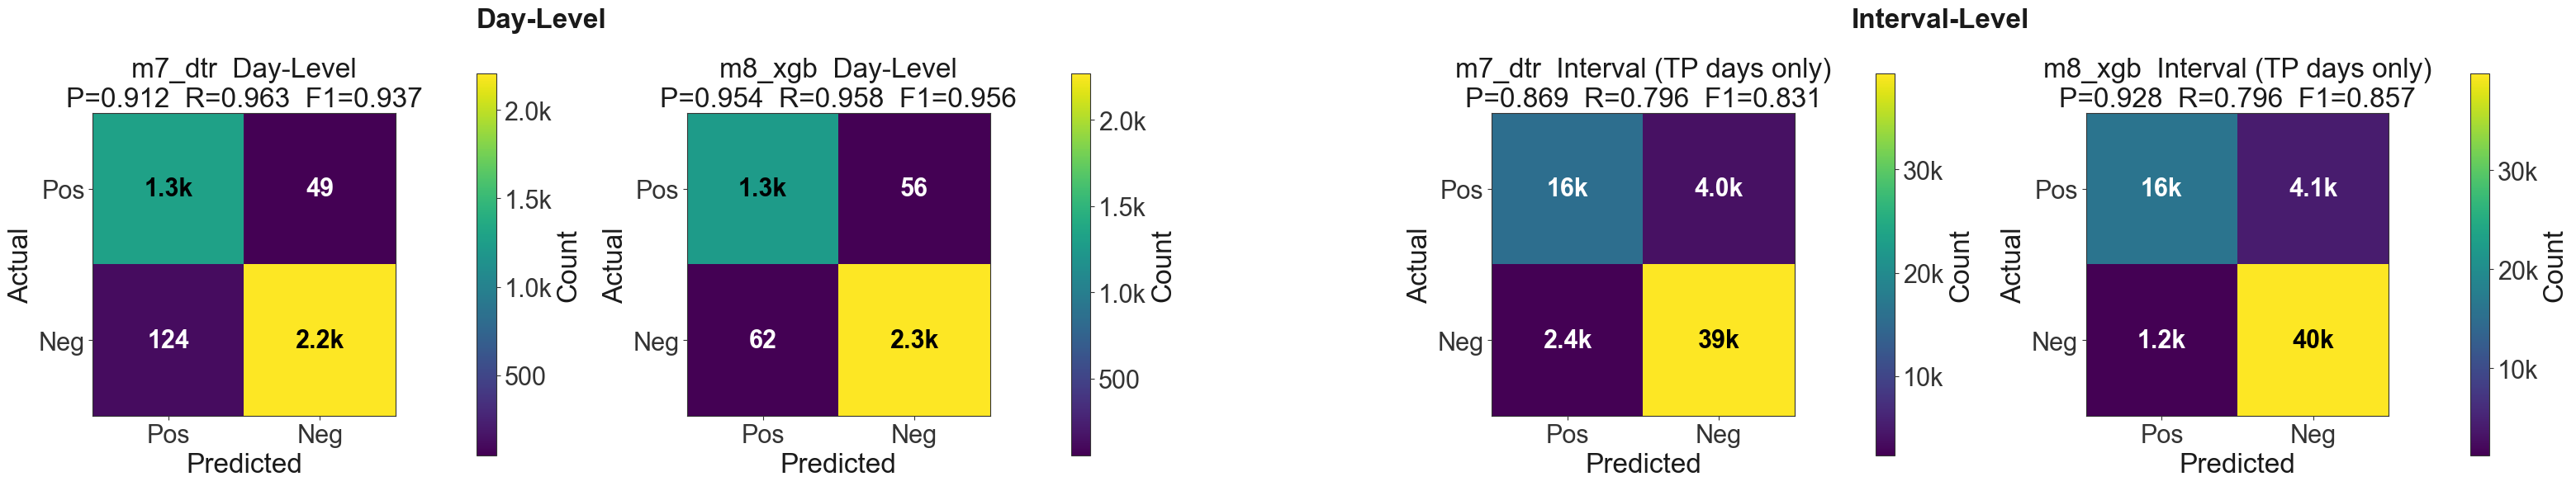

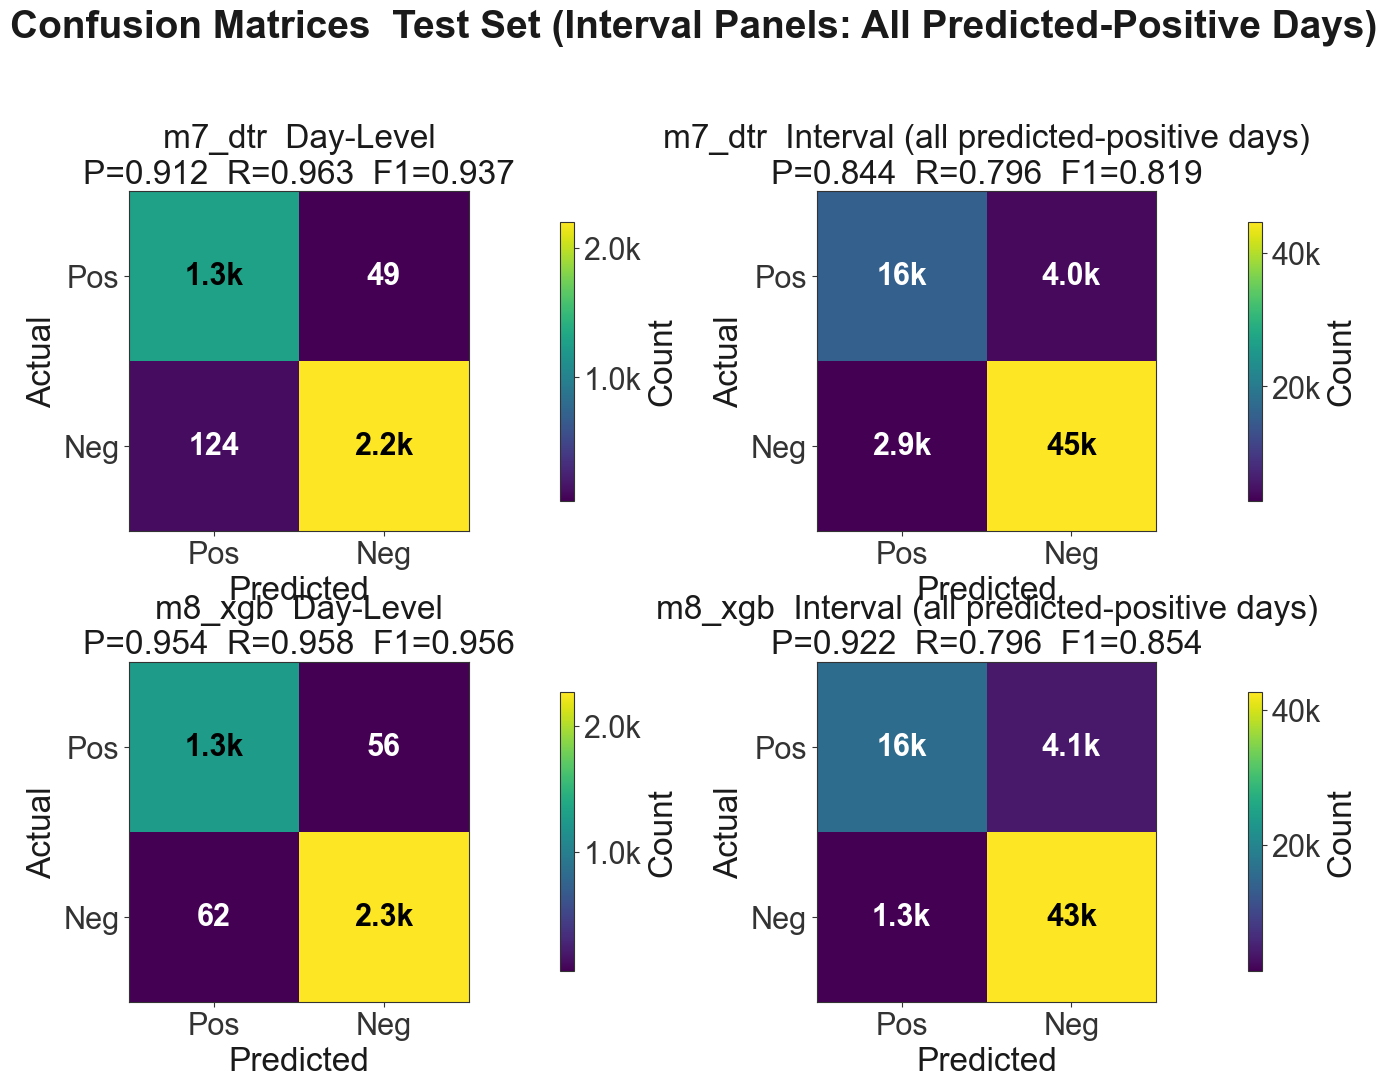

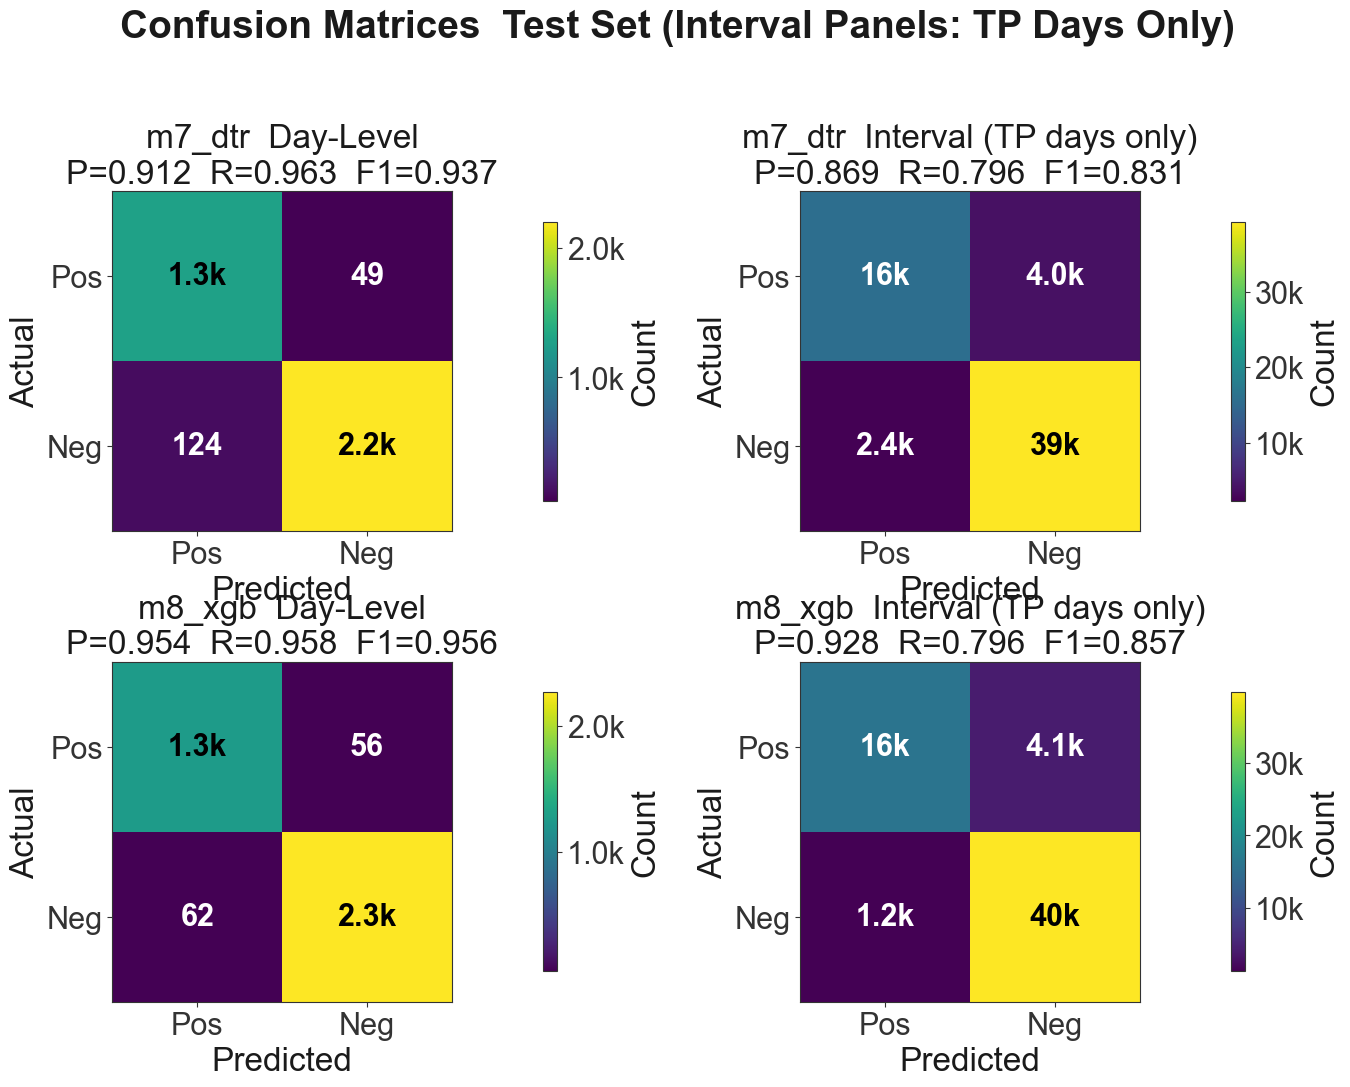

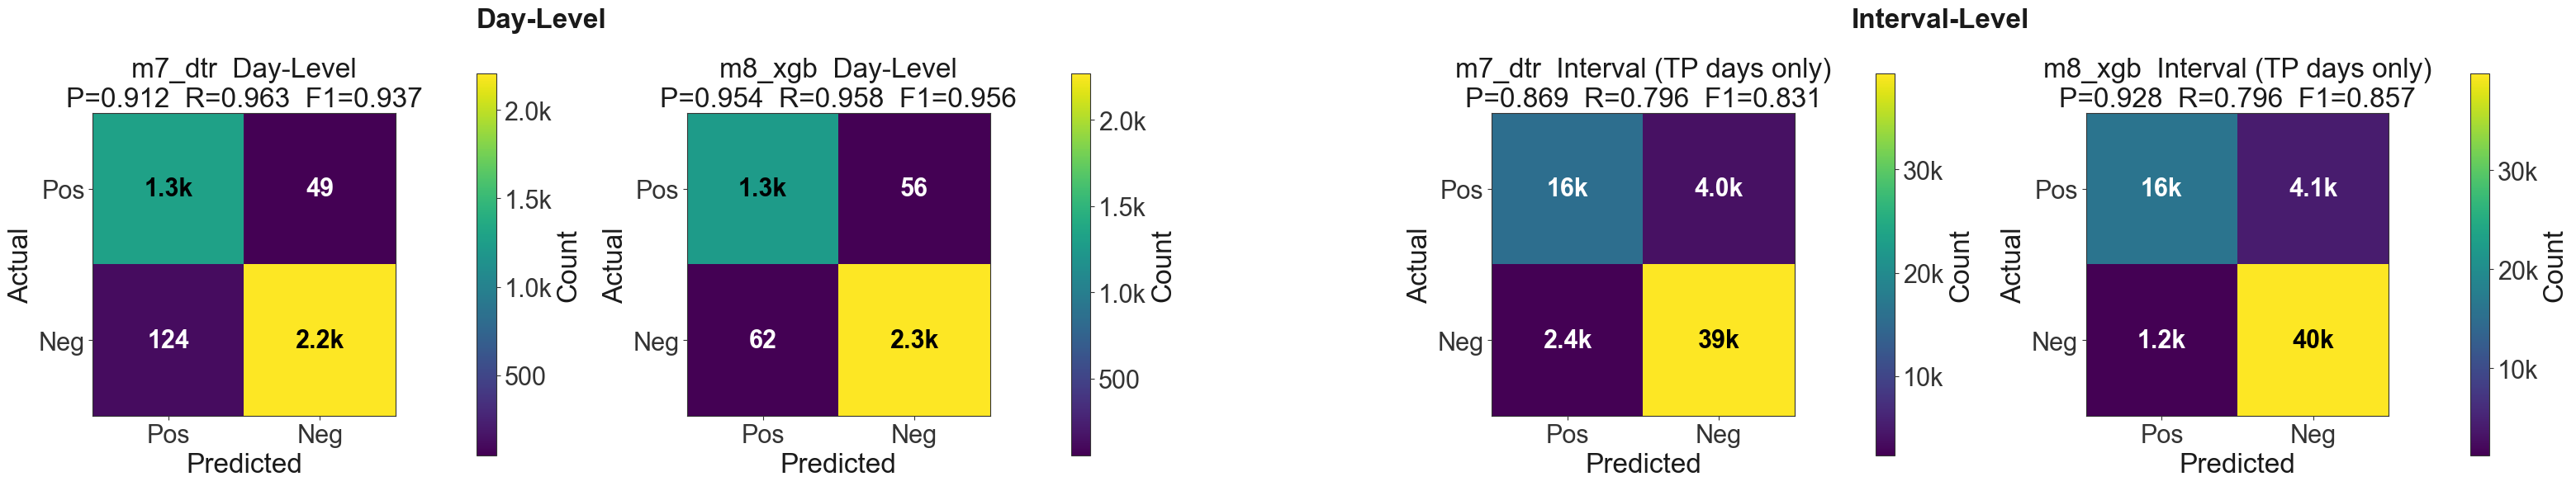

In [12]:
#  Figure 5: confusion matrices (single source: metrics JSON)
def _format_k(value: float) -> str:
    if abs(value) >= 1000:
        k = value / 1000.0
        return f"{k:.1f}k" if abs(k) < 10 else f"{k:.0f}k"
    return f"{int(round(value))}"


def _counts_to_metrics(counts: dict) -> dict:
    tp = int(counts["tp"])
    fp = int(counts["fp"])
    fn = int(counts["fn"])
    tn = int(counts["tn"])
    p = tp / (tp + fp) if (tp + fp) else 0.0
    r = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": round(p, 3),
        "recall": round(r, 3),
        "f1": round(f1, 3),
    }


def _plot_cm_with_cbar_counts(ax, fig, counts, title):
    m = _counts_to_metrics(counts)
    cm = np.array([[m["tp"], m["fn"]], [m["fp"], m["tn"]]], dtype=float)

    im = ax.imshow(cm, interpolation="nearest", cmap="viridis")
    cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.18)
    cbar.set_label("Count", fontsize=24)
    cbar.ax.tick_params(labelsize=22)
    cbar.formatter = mtick.FuncFormatter(lambda x, pos: _format_k(x))
    cbar.update_ticks()

    for i in range(2):
        for j in range(2):
            val = int(cm[i, j])
            colour = "white" if val < cm.max() * 0.5 else "black"
            ax.text(j, i, _format_k(val), ha="center", va="center", fontsize=22, fontweight="bold", color=colour)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pos", "Neg"], fontsize=22)
    ax.set_yticklabels(["Pos", "Neg"], fontsize=22)
    ax.set_xlabel("Predicted", fontsize=24)
    ax.set_ylabel("Actual", fontsize=24)
    ax.set_title(f"{title}\nP={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}", fontsize=24)
    ax.grid(False)


with METRICS_JSON.open("r", encoding="utf-8") as f:
    metrics = json.load(f)

CM_COUNTS = {
    "m7_dtr": {
        "day": metrics["m7_threshold"]["day"]["test"],
        "interval_all_days": metrics["m7_threshold"]["interval_all_days"]["test"],
        "interval_tp_days_only": metrics["m7_threshold"]["interval_tp_days_only"]["test"],
    },
    "m8_xgb": {
        "day": metrics["m8_xgb"]["day"]["test"],
        "interval_all_days": metrics["m8_xgb"]["interval_all_days"]["test"],
        "interval_tp_days_only": metrics["m8_xgb"]["interval_tp_days_only"]["test"],
    },
}
print(f"Loaded confusion-matrix counts from metrics JSON: {METRICS_JSON}")


def _plot_confusion_publication(cm_counts, interval_tp_only=False, suptitle="Confusion Matrices  Test Set"):
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    fig.suptitle(suptitle, fontsize=28, fontweight="bold", y=0.98)

    labels = ["m7_dtr", "m8_xgb"]
    for r, label in enumerate(labels):
        day_vals = cm_counts[label]["day"]
        _plot_cm_with_cbar_counts(axes[r, 0], fig, day_vals, f"{label}  Day-Level")

        key = "interval_tp_days_only" if interval_tp_only else "interval_all_days"
        suffix = "Interval (TP days only)" if interval_tp_only else "Interval (all predicted-positive days)"
        int_vals = cm_counts[label][key]
        _plot_cm_with_cbar_counts(axes[r, 1], fig, int_vals, f"{label}  {suffix}")

    for ax in axes.ravel():
        ax.grid(False)

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig


def _plot_confusion_publication_1x4(cm_counts, interval_tp_only=True):
    fig = plt.figure(figsize=(31, 8.5))
    gs = fig.add_gridspec(1, 5, width_ratios=[1.0, 1.0, 0.15, 1.0, 1.0], wspace=0.38)
    axes = [
        fig.add_subplot(gs[0, 0]),
        fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[0, 3]),
        fig.add_subplot(gs[0, 4]),
    ]

    labels = ["m7_dtr", "m8_xgb"]
    for idx, label in enumerate(labels):
        day_vals = cm_counts[label]["day"]
        _plot_cm_with_cbar_counts(axes[idx], fig, day_vals, f"{label}  Day-Level")

        key = "interval_tp_days_only" if interval_tp_only else "interval_all_days"
        suffix = "Interval (TP days only)" if interval_tp_only else "Interval (all predicted-positive days)"
        int_vals = cm_counts[label][key]
        _plot_cm_with_cbar_counts(axes[idx + 2], fig, int_vals, f"{label}  {suffix}")

    fig.subplots_adjust(left=0.03, right=0.985, bottom=0.12, top=0.80)
    y1 = max(ax.get_position().y1 for ax in axes)

    subtitle_y = y1 + 0.030
    fig.text(
        (axes[0].get_position().x0 + axes[1].get_position().x1) / 2.0,
        subtitle_y,
        "Day-Level\n\n",
        ha="center",
        va="bottom",
        fontsize=24,
        fontweight="bold",
    )
    fig.text(
        (axes[2].get_position().x0 + axes[3].get_position().x1) / 2.0,
        subtitle_y,
        "Interval-Level\n\n",
        ha="center",
        va="bottom",
        fontsize=24,
        fontweight="bold",
    )
    return fig


fig_legacy_all_daytime_path = ARCHIVE_FIG_DIR / "confusion_matrices_all_daytime.png"
fig_legacy_tp_only_path = ARCHIVE_FIG_DIR / "confusion_matrices_tp_days_only_interval.png"
fig5_path = PUB_FIG_DIR / "fig05_confusion_matrices_1x4.png"

fig_legacy_all = _plot_confusion_publication(
    CM_COUNTS,
    interval_tp_only=False,
    suptitle="Confusion Matrices  Test Set (Interval Panels: All Predicted-Positive Days)",
)
fig_legacy_all.savefig(fig_legacy_all_daytime_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_legacy_all_daytime_path}")

fig_legacy_tp = _plot_confusion_publication(
    CM_COUNTS,
    interval_tp_only=True,
    suptitle="Confusion Matrices  Test Set (Interval Panels: TP Days Only)",
)
fig_legacy_tp.savefig(fig_legacy_tp_only_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_legacy_tp_only_path}")

fig5 = _plot_confusion_publication_1x4(
    CM_COUNTS,
    interval_tp_only=True,
)
fig5.savefig(fig5_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig5_path}")

print("\nPublication figures generated:")
for p in [
    fig1_path,
    fig2_path,
    fig3_path,
    fig4_path,
    fig_legacy_all_daytime_path,
    fig_legacy_tp_only_path,
    fig5_path,
]:
    print(f"  - {p}")

fig5
